# Redes neuronales

Cuestionario 4 de la asignatura Aprendizaje Automático del Máster Universitario en
Lógica, Computación e Inteligencia Artificial.

Realizado por Manuel Enciso Martínez.

Para este trabajo, hemos utilizado el dataset: Borzooei, S. & Tarokhian, A. (2023). Differentiated Thyroid Cancer Recurrence [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5632J.

In [125]:
# Imports copiados del cuestionario hecho en clase

import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from sklearn.datasets import make_circles, make_moons, load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy import stats
import numpy as np


# Imports nuevos
from sklearn.preprocessing import OrdinalEncoder #pasar de df string a numerico
from matplotlib.colors import ListedColormap #colores personalizados en scatter matrix
from sklearn.neural_network import MLPClassifier #El módulo para trabajar con redes neuronales en scikit_learn es `neural_network`, y dentro del mismo `MLPClassifier` nos permitirá usar las redes multicapa
import random #para generar números aleatorios

Vamos a comenzar en la parte 1º, reproduciendo los pasos hechos en clase. 

Continuaremos en la parte 2º y 3º, con el análisis y estudio ampliado de la clasificación usando perceptrones multicapa. Al introducir algún cambio en el modelo, vamos a tratar de redactar los razonamientos extraídos de dichos cambios.

## Parte 1º, reproducir los pasos vistos en clase.

In [126]:

# Cargar el archivo DATA.csv (subido a los archivos locales del google colab)
df_Thyroid_Diff = pd.read_csv('C:/Users/encis/Documents/US/Asignaturas/AA/Thyroid_Diff.csv')

# Mostrar las primeras 5 filas del DataFrame
display(df_Thyroid_Diff.head())

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [127]:
feature_names = [
    'Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
    'Thyroid Function', 'Physical Examination', 'Adenopathy',
    'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response'
]

print("Claves: {}".format(df_Thyroid_Diff.keys()))

Claves: Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


A continuación proporcionamos la información respecto de las distintas columnas y el signifcado equivalente de los posibles valores a tomar.

| Columna | Nombre | Categoría | Descripción | Valores |
|---|---|---|---|---|
| 1 | Age | Demográfico | Age at diagnosis in years | Numeric values (range: 15-82 years) |
| 2 | Gender | Demográfico | Biological sex of the patient | Female, Male |
| 3 | Smoking | Estilo de vida/factores de riesgo | Current smoking status at time of diagnosis | Yes, No |
| 4 | Hx Smoking | Estilo de vida/factores de riesgo | Past smoking history | Yes, No |
| 5 | Hx Radiothreapy | Exposición/factores de riesgo | History of radiation therapy to the head and neck region | Yes, No |
| 6 | Thyroid Function | Clínico | Classification of thyroid function status | Euthyroid, Clinical Hypothyroidism, Subclinical Hypothyroidism, Clinical Hyperthyroidism, Subclinical Hyperthyroidism |
| 7 | Physical Examination | Clínico | Presence and type of goiter on physical examination | Normal, Diffuse, Single Nodular Goiter - Right Lobe, Single Nodular Goiter - Left Lobe, Multinodular |
| 8 | Adenopathy | Clínico | Presence of adenopathy (enlarged lymph nodes) on physical examination | No Adenopathy, Right-sided, Left-sided, Bilateral, Posterior, Extensive |
| 9 | Pathology | Patología/historial | Histopathological classification of thyroid cancer | Papillary, Micropapillary, Follicular, Hürthle Cell |
| 10 | Focality | Patología/características del tumor | Number of tumor foci within the thyroid gland | Unifocal, Multifocal |
| 11 | Risk | Riesgo | Risk assessment according to American Thyroid Association guidelines | Low Risk, Intermediate Risk, High Risk |
| 12 | T |Dimensiones del tumor | Tumor size and extension (TNM T score) | T1a, T1b, T2, T3a, T3b, T4a, T4b |
| 13 | N | Ganglios linfáticos | Regional lymph node involvement (TNM N score) | N0, N1a, N1b |
| 14 | M | Metástasis | Distant metastasis status (TNM M score) | M0, M1 |
| 15 | Stage - Final Stage | Estado | Final TNM staging classification combining T, N, M | Stage I, Stage II, Stage III, Stage IVA, Stage IVB |
| 16 | Response | Resultado del tratamiento | Response to initial therapy (radioactive iodine ablation and surgery) | Excellent, Biochemical Incomplete, Structurally Incomplete, Indeterminate |
| 17 | Recurred | Recurrencia | Presence of disease recurrence including locoregional and distant metastasis | Yes, No |

Nuestro objetivo será predecir la recurrencia del cáncer de tiroides de un paciente basándonos en las demás categorías.

Nos será mas conveniente trabajar con valores de categorías de tipo numérico en vez de string. Por ello, vamos a hacer uso de 'OrdinalEncoder' para transformar todos los valores a enteros.

In [128]:
# Seleccionamos del dataset todas las columnas de tipo object (todas menos 'Age')
categorical_cols = df_Thyroid_Diff.select_dtypes(include=['object']).columns

# Transformamos las columnas categóricas a numéricas usando OrdinalEncoder
encoder = OrdinalEncoder(dtype=int)
df_Thyroid_Diff[categorical_cols] = encoder.fit_transform(df_Thyroid_Diff[categorical_cols])

# Mostramos las primeras 5 filas del DataFrame transformado
display(df_Thyroid_Diff.head())

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0


Mostramos a continuación el significado númerico de cada categoría con el original.

In [129]:
for i, col in enumerate(categorical_cols):
    mapping = dict(zip(encoder.categories_[i], range(len(encoder.categories_[i]))))
    print(f"Categoría '{col}' transformación: {mapping}")

Categoría 'Gender' transformación: {'F': 0, 'M': 1}
Categoría 'Smoking' transformación: {'No': 0, 'Yes': 1}
Categoría 'Hx Smoking' transformación: {'No': 0, 'Yes': 1}
Categoría 'Hx Radiothreapy' transformación: {'No': 0, 'Yes': 1}
Categoría 'Thyroid Function' transformación: {'Clinical Hyperthyroidism': 0, 'Clinical Hypothyroidism': 1, 'Euthyroid': 2, 'Subclinical Hyperthyroidism': 3, 'Subclinical Hypothyroidism': 4}
Categoría 'Physical Examination' transformación: {'Diffuse goiter': 0, 'Multinodular goiter': 1, 'Normal': 2, 'Single nodular goiter-left': 3, 'Single nodular goiter-right': 4}
Categoría 'Adenopathy' transformación: {'Bilateral': 0, 'Extensive': 1, 'Left': 2, 'No': 3, 'Posterior': 4, 'Right': 5}
Categoría 'Pathology' transformación: {'Follicular': 0, 'Hurthel cell': 1, 'Micropapillary': 2, 'Papillary': 3}
Categoría 'Focality' transformación: {'Multi-Focal': 0, 'Uni-Focal': 1}
Categoría 'Risk' transformación: {'High': 0, 'Intermediate': 1, 'Low': 2}
Categoría 'T' transforma

Separamos el conjunto objetivo del resto de los datos

In [130]:
Y_target = df_Thyroid_Diff['Recurred']
X_features = df_Thyroid_Diff.drop(columns=['Recurred'])

Vamos a representar la matriz de correlación para algunas cateogrias. Vamos a usar ListedColormap para representar de verde al 0 (no hay recurrencia) y por rojo al 1 (si hay recurrencia).

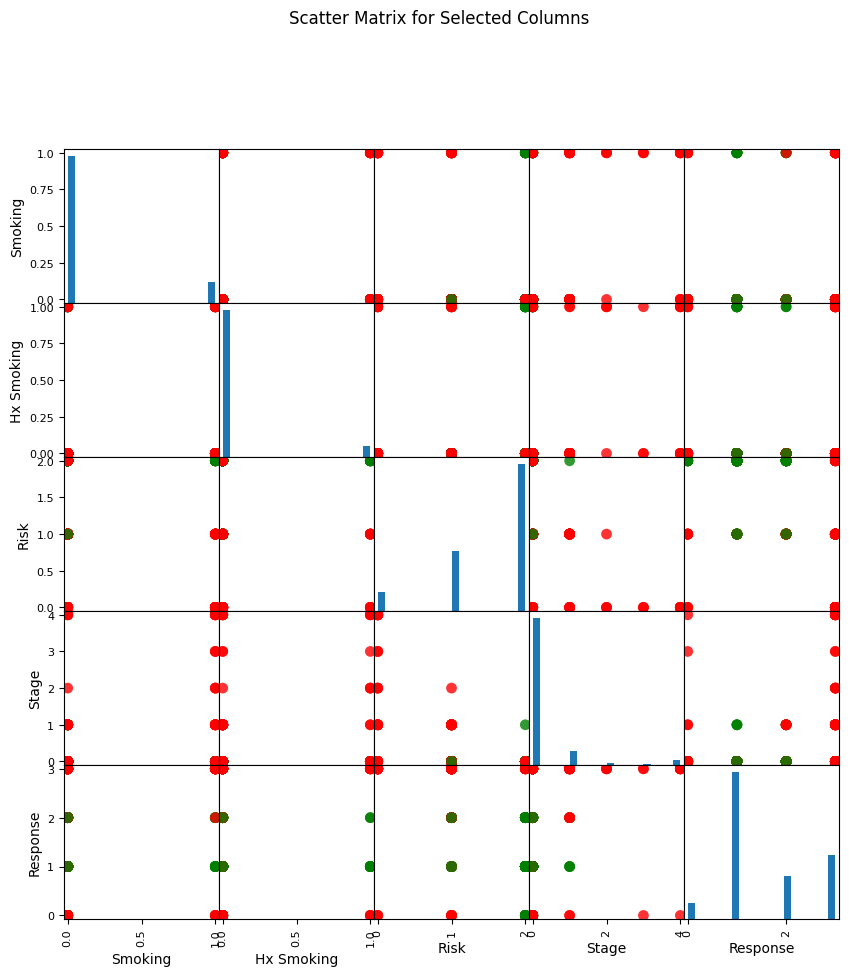

In [131]:
# Create a custom colormap for two classes (green for 0, red for 1)
cmap = ListedColormap(['green', 'red'])


sp_subset = pd.plotting.scatter_matrix(X_features[['Smoking', 'Hx Smoking', 'Risk', 'Stage', 'Response']], c=Y_target, figsize=(10, 10), marker='o',
                                    hist_kwds={'bins': 20}, s=60, alpha=.8,cmap=cmap)
plt.suptitle('Scatter Matrix for Selected Columns', y=1.02) 
plt.show()



Para obtener más información sobre el conjunto de datos, pasemos a analizar los outlayers

Empezamos por visualizar los outlayers en una gráfica de cajas y bigotes.

<Axes: >

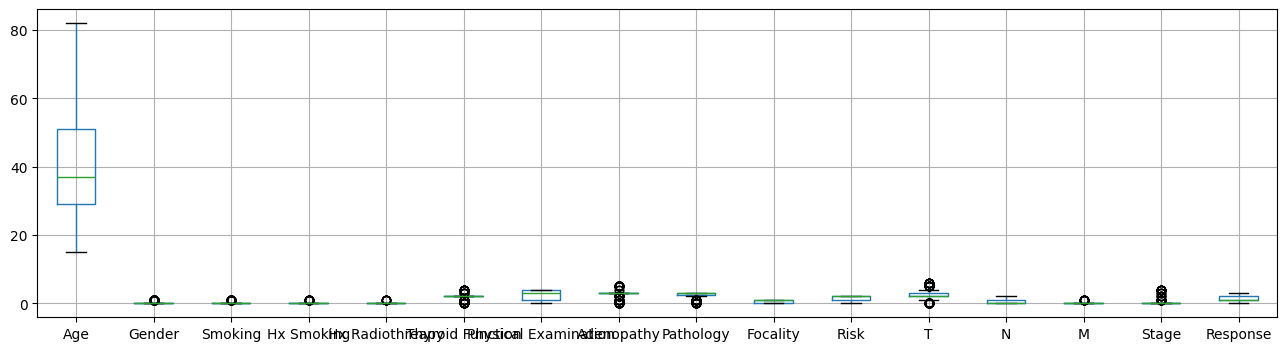

In [132]:
mpl.rcParams['figure.figsize'] = (16,4)
X_features.boxplot()

Vamos a redimensionar de un espacio 16D a otro de 3D usando TSNE en función de la categoría objetiva recurrido.

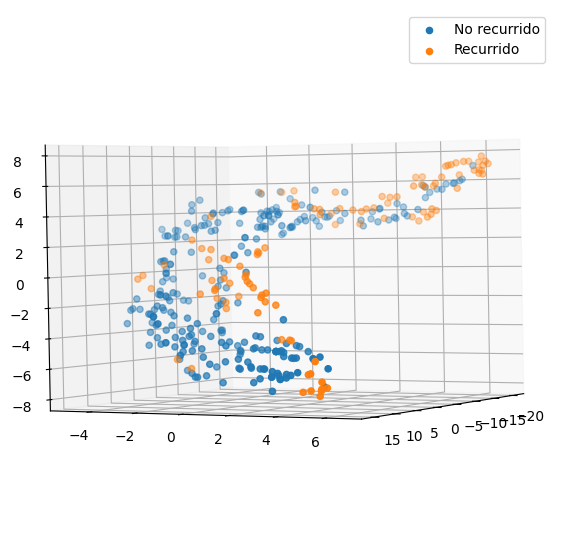

In [133]:
nuevo_tsne_3d = TSNE(n_components=3, random_state=10, perplexity=25.0,init='random',learning_rate='auto')
nuevo_X_3d = nuevo_tsne_3d.fit_transform(X_features)

target_ids = range(len(Y_target.unique()))

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')



for i, label in zip(target_ids, Y_target.unique()):
    ax.scatter(nuevo_X_3d[Y_target == i, 0],
               nuevo_X_3d[Y_target == i, 1],
               nuevo_X_3d[Y_target == i, 2],label=('No recurrido' if label == 0 else 'Recurrido'))

ax.azim = 30
ax.roll = 1
ax.elev = 1.5

plt.legend()
plt.show()

Observamos que hay secciones de nubes de puntos que predominan no recurrido, con algunos pocos recurrido entre ellos. Y zonas donde las nubes de puntos se mezclan más y resulta dificil visualizar una frontera clara.

Vamos a centrarnos en aquellos que destacan más, por tener más outlayers

<Axes: >

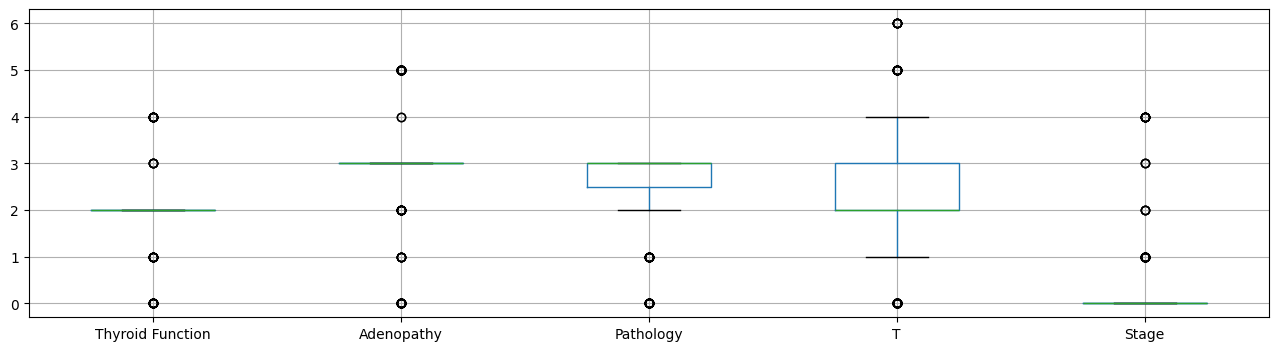

In [134]:
X_features[['Thyroid Function', 'Adenopathy', 'Pathology', 'T', 'Stage']].boxplot()

Visualizamos la nube de puntos para estas categorías

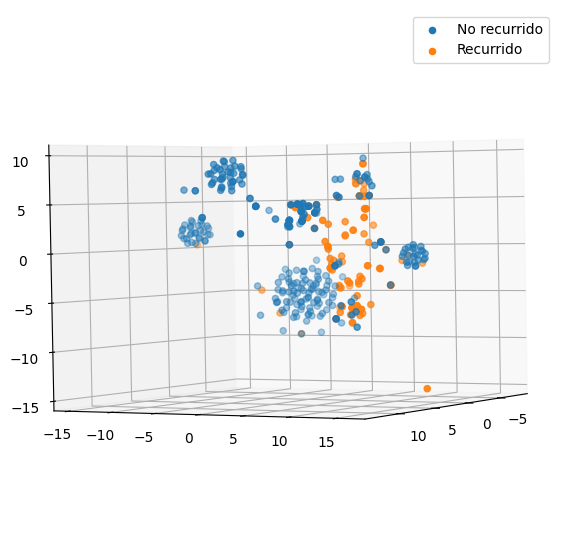

In [135]:
nuevo_tsne_3d = TSNE(n_components=3, random_state=10, perplexity=25.0,init='random',learning_rate='auto')
nuevo_X_3d = nuevo_tsne_3d.fit_transform(X_features[['Thyroid Function', 'Adenopathy', 'Pathology', 'T', 'Stage']])

target_ids = range(len(Y_target.unique()))

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')



for i, label in zip(target_ids, Y_target.unique()):
    ax.scatter(nuevo_X_3d[Y_target == i, 0],
               nuevo_X_3d[Y_target == i, 1],
               nuevo_X_3d[Y_target == i, 2],label=('No recurrido' if label == 0 else 'Recurrido'))

ax.azim = 30
ax.roll = 1
ax.elev = 1.5

plt.legend()
plt.show()

**Estudiemos más a fondo los outlayers para estas categorías. Vamos a representar, para cada categoría anterior, el porcentaje de individuos que pertecen a las distintas clases.**

In [136]:
total = len(X_features['Age']) #Todas las categorías tienen el mismo total de individuos

for categorias in ['Thyroid Function', 'Adenopathy', 'Pathology', 'T', 'Stage']:
    print("Para la categoría", categorias)
    for i in X_features[categorias].unique():
        sum_occurrences = np.sum(X_features[categorias] == i)
        print("Porcentaje de individuos de la clase", i, ":", sum_occurrences / total * 100, "%")
    print("\n")

Para la categoría Thyroid Function
Porcentaje de individuos de la clase 2 : 86.68407310704961 %
Porcentaje de individuos de la clase 0 : 5.221932114882506 %
Porcentaje de individuos de la clase 1 : 3.1331592689295036 %
Porcentaje de individuos de la clase 3 : 1.3054830287206265 %
Porcentaje de individuos de la clase 4 : 3.6553524804177546 %


Para la categoría Adenopathy
Porcentaje de individuos de la clase 3 : 72.32375979112271 %
Porcentaje de individuos de la clase 5 : 12.532637075718014 %
Porcentaje de individuos de la clase 1 : 1.8276762402088773 %
Porcentaje de individuos de la clase 2 : 4.43864229765013 %
Porcentaje de individuos de la clase 0 : 8.355091383812011 %
Porcentaje de individuos de la clase 4 : 0.5221932114882507 %


Para la categoría Pathology
Porcentaje de individuos de la clase 2 : 12.532637075718014 %
Porcentaje de individuos de la clase 3 : 74.93472584856397 %
Porcentaje de individuos de la clase 0 : 7.310704960835509 %
Porcentaje de individuos de la clase 1 : 5.2

Podemos considerar que hay clases de categorias con poca representación, por ejemplo para la categoría Stage tan solo el 0.78% pertenecen a la clase 3. Los datos obtenidos pueden no ser lo suficientemente representativos para obtener conclusiones fiables. Por ello, vamos a considerar que cualquier clase con menos del umbral del 1% (menos de 4 pacientes) quedará eliminada para el estudio.

In [137]:
total = len(X_features['Age'])
df_Thyroid_Diff_nueva = df_Thyroid_Diff.copy()

for categorias in df_Thyroid_Diff.keys().drop('Recurred'):
    for i in X_features[categorias].unique():
        sum_occurrences = np.sum(X_features[categorias] == i)
        porcentaje = sum_occurrences / total
        if porcentaje < 0.01:
            df_Thyroid_Diff_nueva = df_Thyroid_Diff_nueva[df_Thyroid_Diff_nueva[categorias] != i]


Y_target_nuevo = df_Thyroid_Diff_nueva['Recurred']
X_features_nuevo = df_Thyroid_Diff_nueva.drop(columns=['Recurred'])

print("Tamaño original del dataset:", len(X_features))
print("Tamaño del dataset después de eliminar categorías minoritarias:", len(X_features_nuevo))
print("Número de individuos eliminados:", len(X_features) - len(X_features_nuevo))


Tamaño original del dataset: 383
Tamaño del dataset después de eliminar categorías minoritarias: 323
Número de individuos eliminados: 60


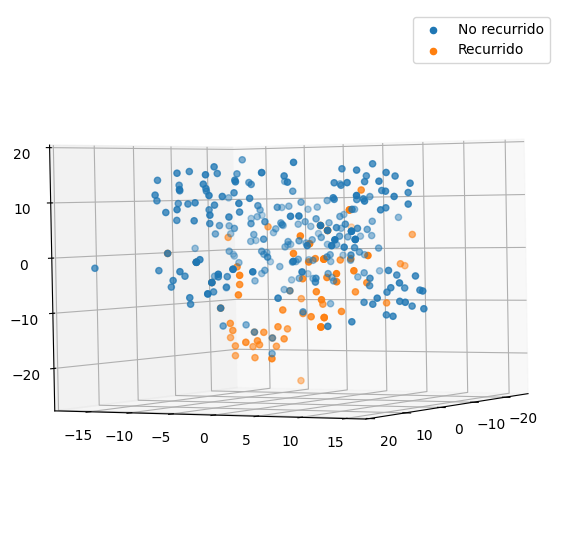

In [138]:
nuevo_tsne_3d = TSNE(n_components=3, random_state=10, perplexity=25.0,init='random',learning_rate='auto')
nuevo_X_3d = nuevo_tsne_3d.fit_transform(X_features_nuevo[['Thyroid Function', 'Adenopathy', 'Pathology', 'T', 'Stage']])

target_ids = range(len(Y_target_nuevo.unique()))

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')



for i, label in zip(target_ids, Y_target_nuevo.unique()):
    ax.scatter(nuevo_X_3d[Y_target_nuevo == i, 0],
               nuevo_X_3d[Y_target_nuevo == i, 1],
               nuevo_X_3d[Y_target_nuevo == i, 2],label=('No recurrido' if label == 0 else 'Recurrido'))

ax.azim = 30
ax.roll = 1
ax.elev = 1.5

plt.legend()
plt.show()

Observamos como las nubes de puntos se pueden distinguir de mejor manera una frontera entre recurrido y no.

Dividimos los datos entre conjunto de entrenamineto y de prueba.

In [139]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_features_nuevo, Y_target_nuevo, stratify=Y_target_nuevo, random_state=42
)

Definimos el modelo de perceptrón multicapa. Empezando con el ejemplo de 2 capas con 10 y 2 neuronas respectivamente.

In [140]:
mlp = MLPClassifier(solver="lbfgs",max_iter=1000,random_state=2026,hidden_layer_sizes=(10,2,))
mlp.fit(X_train, Y_train)

,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,2026


Calculamos el rendimiento después del aprendizaje

In [141]:
print("Rendimiento en entrenamiento: {:.2f}".format(mlp.score(X_train, Y_train)))
print("Rendimiento en el conjunto de prueba: {:.2f}".format(mlp.score(X_test, Y_test)))

Rendimiento en entrenamiento: 0.93
Rendimiento en el conjunto de prueba: 0.86


Veamos como diversas arquitecturas afectan al rendimiento del perceptrón.

Empezando por aumentar las capas y número de neuronas a capas a 10 capas con 10 neuronas cada una.

In [142]:
mlp = MLPClassifier(solver="lbfgs",max_iter=1000,random_state=2026,hidden_layer_sizes=(10,10,10,10,10,10,10,10,10,10,2,))
mlp.fit(X_train, Y_train)

print("Rendimiento en entrenamiento: {:.2f}".format(mlp.score(X_train, Y_train)))
print("Rendimiento en el conjunto de prueba: {:.2f}".format(mlp.score(X_test, Y_test)))

Rendimiento en entrenamiento: 0.90
Rendimiento en el conjunto de prueba: 0.85


Observamos que, aunque hemos aumentando considerablemente el número de capas, apenas hemos obtenido mejoria alguna.

Probemos ahora reduciendo la complejidad a 3 capas con 4, 3, 4 neuronas respectivamente.

In [143]:
mlp = MLPClassifier(solver="lbfgs",max_iter=1000,random_state=2026,hidden_layer_sizes=(4,3,4,))
mlp.fit(X_train, Y_train)

print("Rendimiento en entrenamiento: {:.2f}".format(mlp.score(X_train, Y_train)))
print("Rendimiento en el conjunto de prueba: {:.2f}".format(mlp.score(X_test, Y_test)))

Rendimiento en entrenamiento: 0.90
Rendimiento en el conjunto de prueba: 0.90


Al principio vemos que pasar de 1 capa con 10 neuronas y luego otra de 2, obtiene resultados similares a una red de 10 capas con 10 neuronas y luego otra de 2 neuronas. Lo que siguiere que la profundidad sea un factor tan relevante o que la regularidad en esta profundidad tiene un impacto positivo en el rendimiento. 

Luego hemos comprobado que disminuir a una red de tan solo 3 capas con 4,3,4 neurona obtiene mejores resultados, por lo que reducir la estructura a algo más simple a primera vista puede llegar a ser beneficioso. Siendo un total de menos neuroas pero con mejores resultados. 

A continuación en la parte 2, vamos a tratar de estudiar todo esto con más profundidad.

---

## Parte 2, ampliación.

Como hemos comprobado anteriormente, no parece que haya una estructura mejor a priori. Vamos a comparar los rendimientos obtenidos con distintas arquitecturas, variando el número de capas entre 1 y 10 y las neuronas para cada capa entre 2 y 30. 

Para ello, vamos a hacer uso de la libreria 'random' que nos proporciona generación de numeros aleatorios.

In [144]:
random.seed(2026) #Fijar semilla para reproducibilidad de la libreria random 

Pruebas = 100 #Número de pruebas a realizar

mejor_configuracion = None
mejor_rendimiento_prueba = 0

for iteracion in range(Pruebas):
    length = random.randint(1, 10) #números de capas de la red
    lista = [random.randint(2, 30) for _ in range(length)] #número de neuronas por capa
    mlp = MLPClassifier(solver="lbfgs",max_iter=1000,random_state=2026,hidden_layer_sizes=lista)
    mlp.fit(X_train, Y_train)
    if mlp.score(X_test, Y_test) > mejor_rendimiento_prueba:
        mejor_rendimiento_prueba = mlp.score(X_test, Y_test)
        mejor_configuracion = lista

    print("Prueba número: {}".format(iteracion+1))
    print("Configuración de la red neuronal: {}".format(lista))
    print("Rendimiento en entrenamiento: {:.2f}".format(mlp.score(X_train, Y_train)))
    print("Rendimiento en el conjunto de prueba: {:.2f}".format(mlp.score(X_test, Y_test)))
    print("-------------------------------")

print("\n")
print("Mejor configuración encontrada: {}".format(mejor_configuracion))
print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(mejor_rendimiento_prueba))

Prueba número: 1
Configuración de la red neuronal: [12, 18]
Rendimiento en entrenamiento: 0.94
Rendimiento en el conjunto de prueba: 0.89
-------------------------------
Prueba número: 2
Configuración de la red neuronal: [22, 29, 5, 30, 9, 30, 21, 21, 19]
Rendimiento en entrenamiento: 1.00
Rendimiento en el conjunto de prueba: 0.79
-------------------------------
Prueba número: 3
Configuración de la red neuronal: [27, 20, 19, 28, 25, 26, 26]
Rendimiento en entrenamiento: 1.00
Rendimiento en el conjunto de prueba: 0.89
-------------------------------
Prueba número: 4
Configuración de la red neuronal: [26, 26, 20, 16, 9, 2, 21, 4]
Rendimiento en entrenamiento: 0.77
Rendimiento en el conjunto de prueba: 0.77
-------------------------------
Prueba número: 5
Configuración de la red neuronal: [11, 28]
Rendimiento en entrenamiento: 1.00
Rendimiento en el conjunto de prueba: 0.91
-------------------------------
Prueba número: 6
Configuración de la red neuronal: [16, 2]
Rendimiento en entrenami

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 832 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Prueba número: 84
Configuración de la red neuronal: [19, 27, 17, 30, 27, 23, 20, 11]
Rendimiento en entrenamiento: 1.00
Rendimiento en el conjunto de prueba: 0.90
-------------------------------
Prueba número: 85
Configuración de la red neuronal: [7, 22, 15, 6]
Rendimiento en entrenamiento: 0.98
Rendimiento en el conjunto de prueba: 0.85
-------------------------------
Prueba número: 86
Configuración de la red neuronal: [30, 2, 13, 28, 28, 18, 24, 15]
Rendimiento en entrenamiento: 0.78
Rendimiento en el conjunto de prueba: 0.79
-------------------------------
Prueba número: 87
Configuración de la red neuronal: [22]
Rendimiento en entrenamiento: 0.94
Rendimiento en el conjunto de prueba: 0.84
-------------------------------
Prueba número: 88
Configuración de la red neuronal: [4, 11, 13]
Rendimiento en entrenamiento: 0.77
Rendimiento en el conjunto de prueba: 0.77
-------------------------------
Prueba número: 89
Configuración de la red neuronal: [25, 10, 6, 24, 25, 5, 30, 2, 19]
Rendimi

Para la arquitectura [21, 27, 7, 6, 20, 18, 8, 15, 21, 12] obtenemos el mejor resultado con un rendimiento sobre el conjunto de pruebas del 0.93.

Podemos recopilar las distintas arquitecturas que han obtenido rendimientos superiores al 0.90 en la siguiente tabla:

| nº capas | arquitectura                                      | rendimiento entrenamiento | rendimiento prueba |
|---------|---------------------------------------------------|---------------------------|--------------------|
| 10      | [22, 17, 15, 13, 27, 26, 30, 26, 30, 19]          | 1.00                      | 0.90               |
| 8       | [19, 27, 17, 30, 27, 23, 20, 11]                  | 1.00                      | 0.90               |
| 2       | [23, 13]                                          | 1.00                      | 0.90               |
| 3       | [2, 13, 29]                                       | 0.97                      | 0.90               |
| 6       | [22, 13, 26, 2, 2, 18]                            | 1.00                      | 0.91               |
| 3       | [27, 27, 20]                                      | 1.00                      | 0.90               |
| 8       | [27, 18, 17, 13, 8, 10, 24, 17]                   | 1.00                      | 0.91               |
| 9       | [30, 23, 5, 24, 21, 15, 17, 6, 17]                | 1.00                      | 0.90               |
| 10      | [11, 2, 29, 24, 13, 13, 16, 15, 4, 14]            | 0.99                      | 0.90               |
| 9       | [19, 11, 11, 16, 6, 30, 22, 24, 24]               | 1.00                      | 0.90               |
| 2       | [11, 28]                                          | 1.00                      | 0.91               |

In [145]:
# Número de capas
n_capas = [10, 8, 2, 3, 6, 3, 8, 9, 10, 9, 2]

# Arquitecturas (lista de listas)
arquitecturas = [
    [22, 17, 15, 13, 27, 26, 30, 26, 30, 19],
    [19, 27, 17, 30, 27, 23, 20, 11],
    [23, 13],
    [2, 13, 29],
    [22, 13, 26, 2, 2, 18],
    [27, 27, 20],
    [27, 18, 17, 13, 8, 10, 24, 17],
    [30, 23, 5, 24, 21, 15, 17, 6, 17],
    [11, 2, 29, 24, 13, 13, 16, 15, 4, 14],
    [19, 11, 11, 16, 6, 30, 22, 24, 24],
    [11, 28]
]

# Rendimiento en entrenamiento
rendimiento_entrenamiento = [1.00, 1.00, 1.00, 0.97, 1.00, 1.00, 1.00, 1.00, 0.99, 1.00, 1.00]

# Rendimiento en prueba
rendimiento_prueba = [0.90, 0.90, 0.90, 0.90, 0.91, 0.90, 0.91, 0.90, 0.90, 0.90, 0.91]

print("Media de capas:", sum(n_capas) / len(n_capas))
print("\n")
for n in range(10): #como el minimo de capas es 2, vamos a calcular la media de neuronas por capa para las 2 primeras capas solo
    suma_neuronas = 0
    suma_redes = 0
    for i in range(len(arquitecturas)):
        if n >= len(arquitecturas[i]):
            continue
        else:
            arquitecturas[i][n] #accedemos a la capa n-ésima de la arquitectura i-ésima
            suma_neuronas += arquitecturas[i][n]
            suma_redes += 1
    print("Media de neuronas en la capa " + str(n+1) + ": {:.2f}".format(suma_neuronas / suma_redes))




Media de capas: 6.363636363636363


Media de neuronas en la capa 1: 19.36
Media de neuronas en la capa 2: 17.45
Media de neuronas en la capa 3: 18.78
Media de neuronas en la capa 4: 17.43
Media de neuronas en la capa 5: 14.86
Media de neuronas en la capa 6: 19.29
Media de neuronas en la capa 7: 21.50
Media de neuronas en la capa 8: 16.50
Media de neuronas en la capa 9: 18.75
Media de neuronas en la capa 10: 16.50


Observamos que los valores medios de neuronas por capas, son valores alrededor del número de categorías.

Destacar que [2, 13, 29] consigue un buen rendimiento, algo poco esperado debido a su arquitectura en comparación con las otras redes. Siendo la configuración de 2 neuronas para la primera capa, un valor muy alejado de las 19 neuronas medias para la primera capa. Aunque luego sube en mayor medidad el número de neuroas de 2 -> 13 -> 29.



Vamos a analizar los pesos de la red, para el caso más simple de una red de 1 capa con 16 neuronas (igual al número de categorías), para estudiar como influyen las categorías a la predicción.

In [146]:
mlp = MLPClassifier(solver="lbfgs",random_state=0,activation='relu',
                    max_iter = 5000,hidden_layer_sizes=(16,))
mlp.fit(X_train, Y_train)

coefs0 = mlp.coefs_[0]
n_features, n_hidden = coefs0.shape
# ========== TABLA 1: Input → Hidden ==========
df_w1 = pd.DataFrame(
    mlp.coefs_[0],
    columns=[f'Hidden_{i}' for i in range(n_hidden)],
    index=feature_names[:n_features])
print("=" * 100)
print("PESOS: INPUT → HIDDEN LAYER")
print("=" * 100)
print(df_w1.round(4))

# ========== TABLA 2: Hidden → Output ==========
df_w2 = pd.DataFrame(
    mlp.coefs_[1],
    columns=['Output (Recurrence)'],
    index=[f'Hidden_{i}' for i in range(n_hidden)])
print("\n" + "=" * 100)
print("PESOS: HIDDEN → OUTPUT LAYER")
print("=" * 100)
print(df_w2.round(4))

PESOS: INPUT → HIDDEN LAYER
                      Hidden_0  Hidden_1  Hidden_2  Hidden_3  Hidden_4  \
Age                    -0.3933    0.0501    0.3583   -5.9587   -0.1645   
Gender                 -0.5608    0.9804   -0.5406    0.3117    0.3611   
Smoking                -0.1030    0.5498   -1.5551    0.0913    0.5764   
Hx Smoking             -0.1450   -0.8438   -0.1714   -0.0548    0.4223   
Hx Radiothreapy        -0.2697   -0.1256    0.2501   -0.3485    0.2761   
Thyroid Function       -0.1875   -0.0237   -1.7372   -0.0676   -0.2374   
Physical Examination   -0.0930    1.0871   -0.2491   -0.6361    0.0532   
Adenopathy              0.3442   -0.1528    2.3830   -0.5256   -0.0117   
Pathology               0.1405    0.1540    0.1220   -0.3778   -1.7349   
Focality                0.4875   -0.8242    1.4445    0.2473    0.1349   
Risk                    0.7781   -2.5388   -1.2639    0.0358    0.4796   
T                      -0.8724    2.9227   -0.2478   -0.5369   -0.1982   
N         

Vamos a analizar los pesos de la red, sabiendo que RELU es la función de activación y que para un output de 0 se considera que no hay recurrencia y valor de 1 si la hay.

Hay que tener en cuenta que, a diferencia del resto de categorías, la categoría 'Age' tiene valores enteros entre 18 y 85. Mientras que el resto tan solo toma valores comprendidos entre 0 y 6 (la mayoría entre 0 y 1).

Mostramos en la siguiente tabla, las categorías que más activan/desactivan cada capa y el peso final de cada capa para la predicción.

| Capa | Categorías que Activan/Desactivan |
|------|-----------------------------------|
| Hidden_0 | **Activan:** Risk (0.7781), Focality (0.4875), Adenopathy (0.3442) \| **Desactivan:** N (-0.9926), T (-0.8724), Response (-0.8034) |
| Hidden_1 | **Activan:** Response (3.9786), T (2.9227), N (2.7649) \| **Desactivan:** Risk (-2.5388), Hx Smoking (-0.8438), Focality (-0.8242) |
| Hidden_2 | **Activan:** Adenopathy (2.3830), Focality (1.4445) \| **Desactivan:** Response (-5.2573), Indicador N(-2.3377) Thyroid Function (-1.7372), Smoking (-1.5551) |
| Hidden_3 | **Activan:** Focality (0.2473) \| **Desactivan:** Age (-5.9587), Examen físico (-0.6361) |
| Hidden_4 | **Activan:** Response (1.3292), Risk (0.4796) \| **Desactivan:** Pathology (-1.7349), Medidor N (-0.4065) |
| Hidden_5 | **Activan:** Gender (1.0646), Response (0.9813), Stage (0.9068) \| **Desactivan:** Risk (-1.3807), Adenopathy (-1.1921) |
| Hidden_6 | **Activan:** Response (7.0503), Age (0.6085), Focality (1.2835) \| **Desactivan:** T (-4.7868), N (-3.1664), Thyroid Function (-0.7279) |
| Hidden_7 | **Activan:** Response (1.7360), N (1.3008), Focality (0.4776) \| **Desactivan:** Risk (-1.1435), Physical Examination (-0.3698) |
| Hidden_8 | **Activan:** Risk (3.0973), Age (1.5332), Adenopathy (1.4556) \| **Desactivan:** Response (-2.5168), Physical Examination (-1.6371), Gender (-1.2980) |
| Hidden_9 | **Activan:** Response (0.0781 neutral), Pathology (0.0746 neutral) \| **Desactivan:** Age (-0.7033), Hx Smoking (-0.2155) |
| Hidden_10 | **Activan:** Pathology (0.7256), Age (0.3499), Hx Radiothreapy (0.2205) \| **Desactivan:** Risk (-0.9420), Adenopathy (-0.5653) |
| Hidden_11 | **Activan:** Focality (0.8812), Risk (1.1728), Adenopathy (0.4912) \| **Desactivan:** Response (-2.5883), N (-2.3497), T (-2.2704) |
| Hidden_12 | **Activan:** Focality (0.4388), Pathology (0.1907), Risk (0.1843) \| **Desactivan:** Response (-0.7034), N (-1.0846), T (-0.6034) |
| Hidden_13 | **Activan:** T (3.4160), N (2.7465), Focality (2.4835) \| **Desactivan:** Response (-11.9042), Risk (-4.5053), Thyroid Function (-3.8248) |
| Hidden_14 | **Activan:** Response (0.3492), Risk (0.2540), N (0.1552) \| **Desactivan:** M (-0.1959), Stage (-0.1923), Gender (-0.2037) |
| Hidden_15 | **Activan:** Pathology (0.3390), Physical Examination (0.2996), M (0.2578) \| **Desactivan:** Response (-0.3603), Focality (-0.3727), Hx Radiothreapy (-0.3298) |

| Capa | Peso Output |
|-----|------------|
| Hidden_0 | -1.5108 |
| Hidden_1 | 3.4530 |
| Hidden_2 | 6.2666 |
| Hidden_3 | 0.2448 |
| Hidden_4 | 0.9681 |
| Hidden_5 | 1.3218 |
| Hidden_6 | 5.4943 |
| Hidden_7 | 1.2178 |
| Hidden_8 | -4.3546 |
| Hidden_9 | 0.3606 |
| Hidden_10 | 0.5662 |
| Hidden_11 | 1.4669 |
| Hidden_12 | 0.4653 |
| Hidden_13 | 5.8053 |
| Hidden_14 | 0.5718 |
| Hidden_15 | -0.0257 |



Las capas que más peso tienen para predecir de que hay recurrencia son la 2,13,6. Estas capas se activan/desactivan con las siguientes categorías:
* Activación: Adenopathy (2), focality (2,13,6), indicadores T y N (13),Response (6)
* Desactivan: Response (2,13), indicador N (2,6), indicador T (6), Thyroid function (2,13,6), Smoking (2), Risk (13)

Valores altos de las categorias de activación hacen que estas neuronas se disparen, proporcionando un alto valor a la neurona de activación para predecir posible recurrencia.
De manera alternativa, altos valores de las categorías de desactivación hacen que estas neuronas no se disparen, proporcionando un posible peso nulo de estas neuronas a la neurona de activación para predecir posible recurrencia. (dependería de la activación o no del resto de neuronas).


Las capas que más peso tienen para predecir de que no hay recurrencia son la 8 y 0. Estas capas se activan/desactivan con las siguientes categorías:
* Activación: Risk (0,8), Focality (0), Adenopathy (0), Age (8), Adenopathy (8)
* Desactivan: indicadores N y T (0), Response (0,8), Physical Examination (8), Gender (8)

Valores altos de las categorias de activación hacen que estas neuronas se disparen, proporcionando un bajo valor (negativos) a la neurona de activación para predecir posible no recurrencia.
De manera alternativa, altos valores de las categorías de desactivación hacen que estas neuronas no se disparen, proporcionando un posible peso nulo de estas neuronas a la neurona de activación para predecir posible no recurrencia. (dependería de la activación o no del resto de neuronas).

Para acabar, vamos a usar distintas funciones de activación para ver como afecta a la arquitectura del perceptrón multicapa.

Mirando la documentación, vemos que podemos aplicar 3 funciones de activación distintas:
| Función | Expresión | Rango |
|---------|-----------|-------|
| **ReLU** | f(x) = max(0, x) | [0, ∞) | 
| **Tanh** | f(x) = (e^x - e^-x)/(e^x + e^-x) | (-1, 1) | 
| **Logistic/Sigmoid** | f(x) = 1/(1 + e^-x) | (0, 1) | 

Nota: se puede aplicar tambien la función identidad, pero tendríamos entonces composiciones de funciones lineales.

In [147]:
random.seed(2026) #Fijar semilla para reproducibilidad de la libreria random 

Pruebas = 100 #Número de pruebas a realizar

mejor_configuracion_lista = []
mejor_rendimiento_prueba_lista = []

funciones = ['relu', 'tanh', 'logistic']

for funcion in funciones:
    mejor_rendimiento_prueba = 0
    mejor_configuracion = None
    for iteracion in range(Pruebas):
        length = random.randint(1, 10) #números de capas de la red
        lista = [random.randint(2, 30) for _ in range(length)] #número de neuronas por capa
        mlp = MLPClassifier(solver="lbfgs",max_iter=1000,random_state=2026,hidden_layer_sizes=lista, activation=funcion)
        mlp.fit(X_train, Y_train)
        if mlp.score(X_test, Y_test) > mejor_rendimiento_prueba:
            mejor_rendimiento_prueba = mlp.score(X_test, Y_test)
            mejor_configuracion = lista
    mejor_rendimiento_prueba_lista.append(mejor_rendimiento_prueba)
    mejor_configuracion_lista.append(mejor_configuracion)
    
print("\n")
for i, funcion in enumerate(funciones):
    print("Función de activación: {}".format(funcion))
    print("Mejor configuración encontrada: {}".format(mejor_configuracion_lista[i]))
    print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(mejor_rendimiento_prueba_lista[i]))
    print("\n")

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 832 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\skl



Función de activación: relu
Mejor configuración encontrada: [21, 27, 7, 6, 20, 18, 8, 15, 21, 12]
Mejor rendimiento en el conjunto de prueba: 0.93


Función de activación: tanh
Mejor configuración encontrada: [18, 10, 21, 22, 13, 4, 19, 24]
Mejor rendimiento en el conjunto de prueba: 0.93


Función de activación: logistic
Mejor configuración encontrada: [15]
Mejor rendimiento en el conjunto de prueba: 0.93




c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Observamos que el rendimiento maximo sobre el conjunto de pruebas es el mismo para todos. Aunque para cada función, se obtienen arquitecturas de perceptrón multicapa distintas:
* Para **relu** se obtiene la arquitectura **[21, 27, 7, 6, 20, 18, 8, 15, 21, 12]**. Se pueden destacar grandes saltos del número de neuronas entre una capa y la siguiente, además de alcanzar la longitud máxima establecida de 10 capas. Resulta ser la computacionalmente más eficiente, por la defición tan simple. Podría ser interesenta ampliar el estudio variando los parámetros a redes más profundas y con mayor número de neuronas. Para saber si mejora el rendimiento y sigue muestre el algún patrón parecido.

* Para **tanh** se obtienen la arquitectura **[18, 10, 21, 22, 13, 4, 19, 24]**. Esta vez el número de capas es más reducido, al igual que la diferencia entre neuronas de una capa a la siguiente. Esta función permite que las neuronas que se disparen con valores positivos, pueden tomar tambien valores negativos lo cual la hace más compleja e interesante de estudio (los pesos cobran doble función de activación/desactivación). Resulta ser computacionalmente más costosa al tener que calcular exponenciales, pudiendo ser menos eficiente computacionalmente a una posible ampliación más profunda.

* Para **logistic** (sigmoide) se obtienen la arquitectura **[15]**. Esta es la más sencilla de todas, con tan solo una capa oculta de un número similar a la dimensión (número de categorías). Esta función limita la activación a valores entre 0 y 1, por lo cual podría ser interesante ampliar el estudio viendo el papel que juegan los pesos para esta función y compararlos con los estudiados para relu. Computacionalmente es más eficiente que la tanh, podría estudiarse una posible ampliación y comparación con la anterior en terminos de convergencias.

Al final todas consiguen el mismo rendimiento, lo que parece más curioso es con la arquitectura con la que lo consiguen tan diferentes unas de otras. Nos llevaría mucho más tiempo dar una causa definitiva de este comportamiento para estudiarlo con profundidad.